### Import

In [1]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Download latest version

In [2]:
path = kagglehub.dataset_download("pranshuljoshi/global-startup-funding-and-valuation-cleaned-dataset")
print("Path to dataset files:\n", path)

Path to dataset files:
 C:\Users\VU QUANG HUY\.cache\kagglehub\datasets\pranshuljoshi\global-startup-funding-and-valuation-cleaned-dataset\versions\1


### List files in the dataset directory

In [3]:
print(f"Files in the dataset directory: {os.listdir(path)}\n")

Files in the dataset directory: ['startup_data.csv']



### First 5 rows

In [4]:
file_path = path + "\\startup_data.csv"
df = pd.read_csv(file_path)
print(f"First 5 rows of the dataset:\n{df.head()}")

First 5 rows of the dataset:
  Startup Name Industry  Funding Rounds  Funding Amount (M USD)  \
0    Startup_1      IoT               1                  101.09   
1    Startup_2   EdTech               1                  247.62   
2    Startup_3   EdTech               1                  109.24   
3    Startup_4   Gaming               5                   10.75   
4    Startup_5      IoT               4                  249.28   

   Valuation (M USD)  Revenue (M USD)  Employees  Market Share (%)  \
0             844.75            67.87       1468              5.20   
1            3310.83            75.65       3280              8.10   
2            1059.37            84.21       4933              2.61   
3             101.90            47.08       1059              2.53   
4             850.11            50.25       1905              4.09   

   Profitable  Year Founded         Region Exit Status  
0           0          2006         Europe     Private  
1           1          2003  Sout

### Exploring dataset

In [5]:
df

,Startup Name,Industry,Funding Rounds,Funding Amount (M USD),Valuation (M USD),Revenue (M USD),Employees,Market Share (%),Profitable,Year Founded,Region,Exit Status
0,Startup_1,IoT,1,101.09,844.75,67.87,1468,5.20,0,2006,Europe,Private
1,Startup_2,EdTech,1,247.62,3310.83,75.65,3280,8.10,1,2003,South America,Private
2,Startup_3,EdTech,1,109.24,1059.37,84.21,4933,2.61,1,1995,South America,Private
3,Startup_4,Gaming,5,10.75,101.90,47.08,1059,2.53,0,2003,South America,Private
4,Startup_5,IoT,4,249.28,850.11,50.25,1905,4.09,0,1997,Europe,Acquired
...,...,...,...,...,...,...,...,...,...,...,...,...
495,Startup_496,EdTech,2,181.86,2378.65,59.64,3331,0.58,1,1993,Europe,Private
496,Startup_497,AI,2,107.34,1394.58,10.22,2223,5.85,0,2019,South America,Private
497,Startup_498,E-Commerce,1,160.29,502.09,84.73,2222,4.32,0,2019,Australia,Private
498,Startup_499,Gaming,5,234.65,2814.52,53.16,4972,5.53,0,2011,Europe,Private


In [6]:
df.shape

(500, 12)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Startup Name            500 non-null    str    
 1   Industry                500 non-null    str    
 2   Funding Rounds          500 non-null    int64  
 3   Funding Amount (M USD)  500 non-null    float64
 4   Valuation (M USD)       500 non-null    float64
 5   Revenue (M USD)         500 non-null    float64
 6   Employees               500 non-null    int64  
 7   Market Share (%)        500 non-null    float64
 8   Profitable              500 non-null    int64  
 9   Year Founded            500 non-null    int64  
 10  Region                  500 non-null    str    
 11  Exit Status             500 non-null    str    
dtypes: float64(4), int64(4), str(4)
memory usage: 63.3 KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Funding Rounds,Funding Amount (M USD),Valuation (M USD),Revenue (M USD),Employees,Market Share (%),Profitable,Year Founded
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2.958000,152.656760,1371.809180,49.321740,2532.092000,5.092940,0.432000,2006.044000
std,1.440968,86.683711,978.226579,29.267605,1385.434921,2.807646,0.495851,9.347128
min,1.000000,0.570000,2.430000,0.120000,12.000000,0.100000,0.000000,1990.000000
25%,2.000000,79.212500,557.027500,22.802500,1382.750000,2.760000,0.000000,1998.000000
50%,3.000000,156.005000,1222.580000,48.800000,2496.500000,5.135000,0.000000,2006.000000
75%,4.000000,226.450000,2052.085000,74.965000,3708.750000,7.552500,1.000000,2014.000000
max,5.000000,299.810000,4357.490000,99.710000,4984.000000,10.000000,1.000000,2022.000000


In [10]:
corr = df.corr(numeric_only=True)
corr

,Funding Rounds,Funding Amount (M USD),Valuation (M USD),Revenue (M USD),Employees,Market Share (%),Profitable,Year Founded
Funding Rounds,1.000000,-0.050223,-0.067821,0.014539,0.026704,-0.014285,0.033859,-0.014444
Funding Amount (M USD),-0.050223,1.000000,0.795061,0.033103,0.042150,0.062200,0.004792,-0.036959
Valuation (M USD),-0.067821,0.795061,1.000000,0.058219,0.014660,0.103547,0.092499,-0.021101
Revenue (M USD),0.014539,0.033103,0.058219,1.000000,0.013054,-0.012512,0.032159,-0.059215
Employees,0.026704,0.042150,0.014660,0.013054,1.000000,0.030937,0.004114,0.011391
Market Share (%),-0.014285,0.062200,0.103547,-0.012512,0.030937,1.000000,0.115842,-0.008428
Profitable,0.033859,0.004792,0.092499,0.032159,0.004114,0.115842,1.000000,0.019239
Year Founded,-0.014444,-0.036959,-0.021101,-0.059215,0.011391,-0.008428,0.019239,1.000000


Noticeable (>10%):
- Valuation (M USD) - Funding Amount (M USD): [79.5%]
- Profitable - Market Share (%): [11.5%]
- Valuation (M USD)	- Market Share (%): [10.3%]

### Check which industries are profitable

In [11]:
industry = df["Industry"].unique()
industry

<ArrowStringArray>
[          'IoT',        'EdTech',        'Gaming',            'AI',
    'HealthTech',       'FinTech', 'Cybersecurity',    'E-Commerce']
Length: 8, dtype: str

In [12]:
total = df["Industry"].value_counts()
total

Industry
EdTech           74
FinTech          71
E-Commerce       70
Gaming           62
AI               62
IoT              61
Cybersecurity    51
HealthTech       49
Name: count, dtype: int64

In [13]:
profitable = df[df["Profitable"] == 1]["Industry"].value_counts()
profitable

Industry
E-Commerce       38
EdTech           34
IoT              32
AI               29
FinTech          24
HealthTech       22
Gaming           21
Cybersecurity    16
Name: count, dtype: int64

In [14]:
profit_rate = (profitable / total) * 100
profit_rate_sorted =profit_rate.sort_values(ascending=False)
profit_rate_sorted

Industry
E-Commerce       54.285714
IoT              52.459016
AI               46.774194
EdTech           45.945946
HealthTech       44.897959
Gaming           33.870968
FinTech          33.802817
Cybersecurity    31.372549
Name: count, dtype: float64

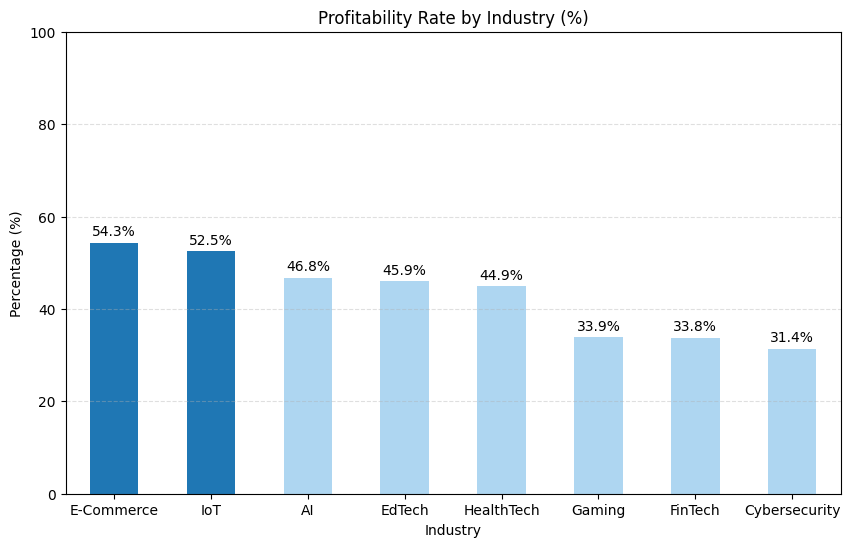

In [15]:
# Draw
colors = ['#1f77b4' if x > 50 else '#aed6f1' for x in profit_rate_sorted]
ax = profit_rate_sorted.plot(kind='bar', figsize=(10, 6), color=colors)


ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3, fontsize=10)

# Set Y-axis limits to 100
plt.ylim(0, 100)

plt.title('Profitability Rate by Industry (%)')
plt.ylabel('Percentage (%)')
plt.xlabel('Industry')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)

Choose 2 industries with the percentage over 50%:
- E-Commerce
- IoT